In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import LogNorm

words = (open('names.txt', 'r').read().splitlines())

In [2]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) + 1
sorted(b.items(), key=lambda kv: kv[1], reverse=True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [3]:
#faster than to use .get
from collections import Counter
c = Counter()
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    c.update(zip(chs, chs[1:]))
c.most_common()
# c.most_common(10) returns 10 most common

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [4]:
chars = sorted(list(set(''.join(words))))
#creates set - list of elements in words
stoi = {s:i+1 for i, s in enumerate(chars)}
#maps each letter to number
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [5]:
# store in array rather than pairs, entry is how often pair occurs
N = torch.zeros((27,27), dtype=torch.int32)
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1

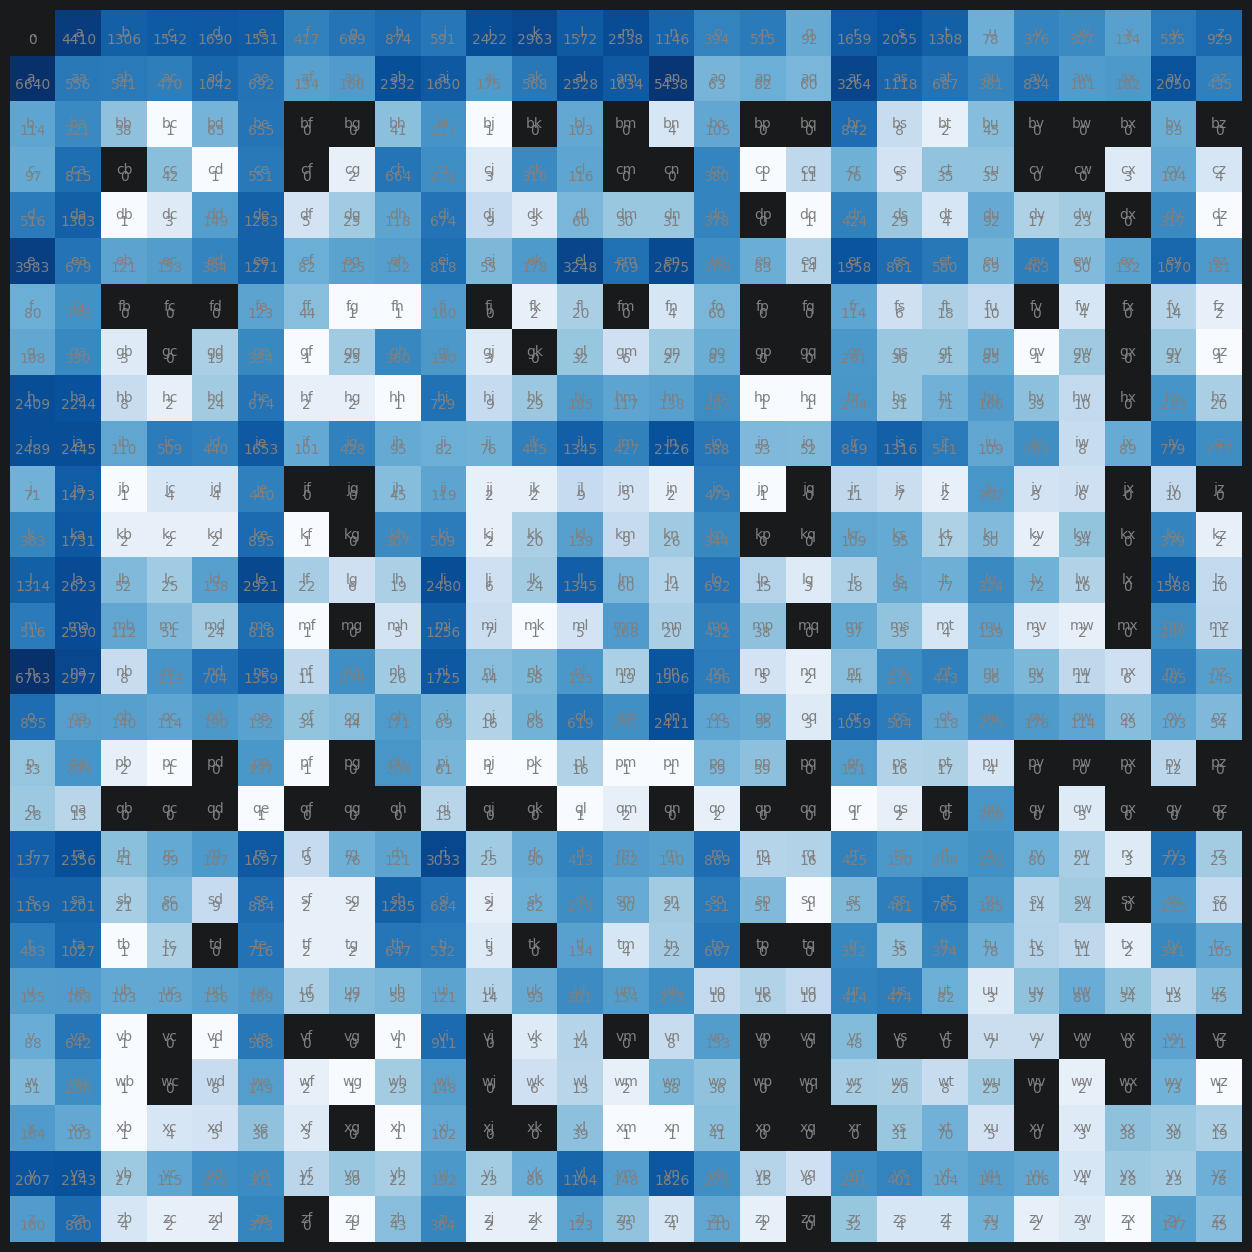

In [6]:
#can print N but better visual using matplotlib
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues', norm=LogNorm())   # log-scaled shading
#plt.imshow(N, cmap='Blues', vmax=500)   #clip the top, saturate outliers
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='center', color='gray')
        plt.text(j, i, N[i,j].item(), ha='center', va='top', color='gray')
plt.axis('off');

In [7]:
#prepare matrix P rather than normalising each row
#N+1 is smoothing: unseen bigrams get nonzero prob (too much -> uniform)
P = (N+1).float()
P /= P.sum(1, keepdim=True) #sums rows, keep dim means it doesnt collapse, then broadcasts, stretches the 27x1 into 27x27

In [8]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [9]:
#loss fn
#Goal: maximise likelihood wrt weights = minimise normalised negative log likelihood
log_likelihood = 0 #MLE: product of probs, should be high - convenient to work with log (small numbers), then take negative so low is better
n = 0 # to normalise
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
nnll = -log_likelihood / n
print(f'nll: {-log_likelihood}')
print(f'nnll: {nnll:.4f}')

nll: 559951.5625
nnll: 2.4544


In [10]:
#vectorised way; same xs/ys are the NN training set below
#(on w in ['andrejq'] the unsmoothed nll = inf -> why P uses N+1)
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
nll = -P[xs, ys].log().mean()
print(f'nll: {nll:.4f}')

nll: 2.4546


In [11]:
#Now cast the bigram in a NN framework; gradient-based opt tunes W via NLL loss
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True) #random via normal dist

for k in range(200):
    #forward
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W #later this is only thing that gets more complex (one prevoius character easier)
    counts = logits.exp()
    probs  = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean() #smoothing similar to adding 1; pushing W to zero pushes logits to 0 so exp = 1 and hence unif
    #adding counts corresp to strengthening regularisation
    if k % 10 == 0:
        print(loss.item())
    #back
    W.grad = None
    loss.backward()

    #update
    W.data += -50 * W.grad



3.76861834526062
2.6965057849884033
2.5822560787200928
2.5413529872894287
2.521263837814331
2.509854793548584
2.5027060508728027
2.4978790283203125
2.494438648223877
2.4918932914733887
2.4899587631225586
2.4884581565856934
2.4872729778289795
2.4863228797912598
2.485551357269287
2.484916925430298
2.484389066696167
2.483945608139038
2.4835691452026367
2.4832472801208496


In [12]:
#finally sample from NN
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix ==0:
            break
    print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
